In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
import os, csv

from helpers import load_data, preprocess, normalize, create_window, train_and_evaluate_models, \
    plot_performance, print_model_summaries, write_model_results_to_csv, WindowGenerator, \
    baseline, linear, dense, simple_rnn, cnn, lstm, autoregressive, bi_lstm, load_all_data, create_csv, \
    calculate_original_performance, drop_feature_and_evaluate, create_feature_csv, plot_training_history, compile_and_fit

2024-11-19 12:39:45.599844: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df = pd.read_csv("./Station3_precipitation_chance_hourly.csv", index_col=0, parse_dates=True)
df = df[~df.index.duplicated(keep='first')]
#df = preprocess(df)
#df = normalize(df)
df = df.drop(columns = ['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20', 'T_50', 'Sum_Rain_1h', 'Sum_Rain_3h', 'Sum_Rain_6h', 'Sum_Rain_12h', 'Sum_Rain_24h'
                        , 'Rain_Chance_Percentage_1d', 'Rain_Chance_Percentage_2d', 'Rain_Chance_Percentage_3d','Rain_Chance_Percentage_4d', 
                        'Rain_Chance_Percentage_5d', 'Rain_Chance_Percentage_6d', 'Rain_Chance_Percentage_7d'])
df = df.drop(columns = ['Wx', 'Wy', 'Tair', 'Ppt.1'])
#df = df.drop(columns = ['Predicted_Rain_Next_Hour_1h', 'Predicted_Rain_Next_Hour_3h', 'Predicted_Rain_Next_Hour_6h', 'Predicted_Rain_Next_Hour_12h', 'Predicted_Rain_Next_Hour_24h'])
df = df.drop(columns = ['Predict_1days_Percentage',
       'Predict_2days_Percentage', 'Predict_3days_Percentage',
       'Predict_4days_Percentage', 'Predict_5days_Percentage',
       'Predict_6days_Percentage', 'Predict_7days_Percentage'])
#df = df.drop(columns = ['Ppt', 'Rain_Chance_Percentage'])
#df = df.drop(columns = ['Day sin', 'Day cos', 'Year sin', 'Year cos'])
df.head()

df.columns


Index(['Ppt', 'RH', 'Srad', 'Day sin', 'Day cos', 'Year sin', 'Year cos',
       'Predicted_Rain_Next_Hour_1h', 'Predicted_Rain_Next_Hour_3h',
       'Predicted_Rain_Next_Hour_6h', 'Predicted_Rain_Next_Hour_12h',
       'Predicted_Rain_Next_Hour_24h', 'Rain_Chance_Percentage'],
      dtype='object')

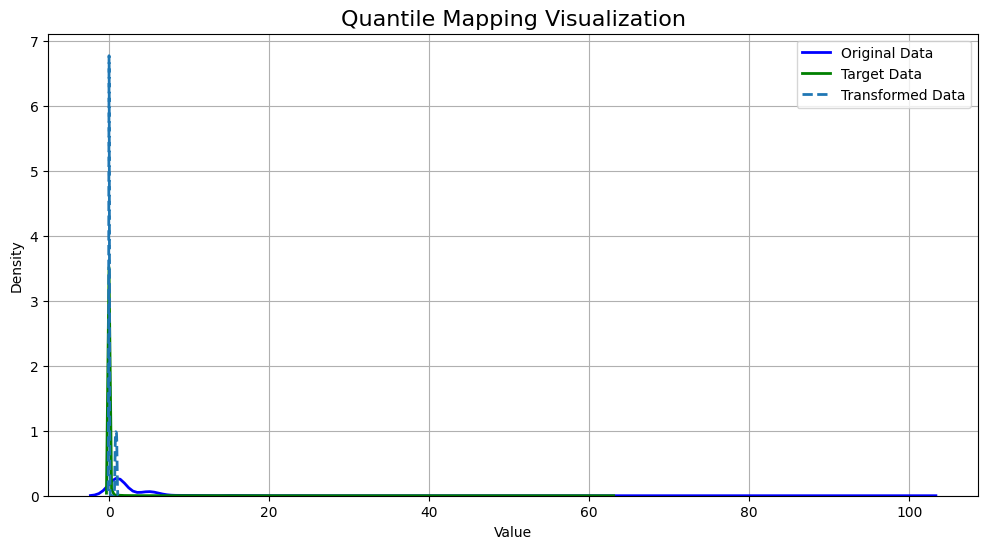

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer

def visualize_quantile_mapping(original_data, target_data, transformed_data, title="Quantile Mapping Visualization"):
    """
    Visualizes quantile mapping by comparing the original, target, and transformed distributions.

    Parameters:
        original_data (pd.Series or np.ndarray): Original data before quantile mapping.
        target_data (pd.Series or np.ndarray): Target data distribution (e.g., actual precipitation).
        transformed_data (pd.Series or np.ndarray): Data after applying quantile mapping.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(12, 6))

    # Plot the original data
    sns.kdeplot(original_data, label='Original Data', color='blue', linewidth=2)
    
    # Plot the target data
    sns.kdeplot(target_data, label='Target Data', color='green', linewidth=2)
    
    # Plot the transformed data
    sns.kdeplot(transformed_data, label='Transformed Data', color='red', linewidth=2, linestyle="--")
    
    plt.title(title, fontsize=16)
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage
original_data = df['Predicted_Rain_Next_Hour_1h']
target_data = df['Ppt']
qt = QuantileTransformer(output_distribution='uniform', random_state=42)
transformed_data = qt.fit_transform(original_data.values.reshape(-1, 1))

visualize_quantile_mapping(original_data, target_data, transformed_data)


In [4]:
# List of prediction columns you want to transform
# prediction_columns = ['Predicted_Rain_Next_Hour_1h', 'Predicted_Rain_Next_Hour_3h', 
#                       'Predicted_Rain_Next_Hour_6h', 'Predicted_Rain_Next_Hour_12h', 
#                       'Predicted_Rain_Next_Hour_24h']

# # Apply logarithmic transformation (log(1 + value)) to each prediction column
# for column in prediction_columns:
#     # Create a new column for the log-transformed values
#     df[f'Log_{column}'] = np.log1p(df[column])  # log1p is log(1 + x) to handle zero values
# df = df.drop(columns = ['Predicted_Rain_Next_Hour_1h', 'Predicted_Rain_Next_Hour_3h', 'Predicted_Rain_Next_Hour_6h', 'Predicted_Rain_Next_Hour_12h', 'Predicted_Rain_Next_Hour_24h'])
# # Show the first few rows of the new columns
# df['Log_Predicted_Rain_Next_Hour_1h_lag1'] = df['Log_Predicted_Rain_Next_Hour_1h'].shift(1)
# df['Log_Predicted_Rain_Next_Hour_1h_lag_2'] = df['Log_Predicted_Rain_Next_Hour_1h'].shift(2)

# df[[f'Log_{column}' for column in prediction_columns]].head()

In [5]:
n = len(df)
print(df.isna().sum())
print(df.isin([np.inf, -np.inf]).sum())
df = df.dropna()
print(df.isna().sum())
print(df.isin([np.inf, -np.inf]).sum())
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

scaler = MinMaxScaler()
train_df_scaled = pd.DataFrame(scaler.fit_transform(train_df), columns=train_df.columns, index=train_df.index)

# Use the same scaler to transform validation and test data
val_df_scaled = pd.DataFrame(scaler.transform(val_df), columns=val_df.columns, index=val_df.index)
test_df_scaled = pd.DataFrame(scaler.transform(test_df), columns=test_df.columns, index=test_df.index)


Ppt                             0
RH                              0
Srad                            0
Day sin                         0
Day cos                         0
Year sin                        0
Year cos                        0
Predicted_Rain_Next_Hour_1h     0
Predicted_Rain_Next_Hour_3h     0
Predicted_Rain_Next_Hour_6h     0
Predicted_Rain_Next_Hour_12h    0
Predicted_Rain_Next_Hour_24h    0
Rain_Chance_Percentage          0
dtype: int64
Ppt                             0
RH                              0
Srad                            0
Day sin                         0
Day cos                         0
Year sin                        0
Year cos                        0
Predicted_Rain_Next_Hour_1h     0
Predicted_Rain_Next_Hour_3h     0
Predicted_Rain_Next_Hour_6h     0
Predicted_Rain_Next_Hour_12h    0
Predicted_Rain_Next_Hour_24h    0
Rain_Chance_Percentage          0
dtype: int64
Ppt                             0
RH                              0
Srad                  

In [6]:
target_columns = ['Predicted_Rain_Next_Hour_1h', 'Predicted_Rain_Next_Hour_3h', 
                  'Predicted_Rain_Next_Hour_6h', 'Predicted_Rain_Next_Hour_12h', 
                  'Predicted_Rain_Next_Hour_24h']
window = create_window(
        input_width=24,
        label_width=1,
        shift=1,
        train_df=train_df_scaled,
        val_df=val_df_scaled,
        test_df=test_df_scaled,
        label_columns=target_columns
    )

df.head()

,Ppt,RH,Srad,Day sin,Day cos,Year sin,Year cos,Predicted_Rain_Next_Hour_1h,Predicted_Rain_Next_Hour_3h,Predicted_Rain_Next_Hour_6h,Predicted_Rain_Next_Hour_12h,Predicted_Rain_Next_Hour_24h,Rain_Chance_Percentage
2015-01-03 00:00:00,0.76,98.9,0.18,-4.722481e-12,1.000000,0.035903,0.999355,22.952321,100.000000,99.944365,58.884462,35.786431,100.0
2015-01-03 01:00:00,0.51,98.6,0.22,2.588190e-01,0.965926,0.036619,0.999329,16.104586,99.790411,99.449693,61.331976,37.545061,100.0
2015-01-03 02:00:00,0.00,99.3,0.04,5.000000e-01,0.866025,0.037336,0.999303,1.000000,14.604544,88.195316,54.944073,32.539845,100.0
2015-01-03 03:00:00,0.00,98.8,0.02,7.071068e-01,0.707107,0.038052,0.999276,1.000000,2.620576,82.754568,54.503591,32.800185,100.0
2015-01-03 04:00:00,0.00,98.0,0.00,8.660254e-01,0.500000,0.038768,0.999248,1.000000,1.000000,73.471257,52.599746,33.306184,100.0


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_prediction_distributions(df, prediction_columns, bins=30, title='Prediction Distributions'):
    """
    Plots the distribution of multiple prediction columns in the DataFrame.
    
    Parameters:
        df (pd.DataFrame): The DataFrame containing the prediction columns.
        prediction_columns (list): A list of column names (strings) to plot.
        bins (int): Number of bins for the histogram.
        title (str): The title of the plot.
    """
    # Set up the matplotlib figure
    plt.figure(figsize=(14, 8))
    
    # Loop through each prediction column and plot its distribution
    for column in prediction_columns:
        sns.histplot(df[column], bins=bins, kde=True, label=column, stat='density', alpha=0.6)
    
    # Add labels and title
    plt.title(title, fontsize=16)
    plt.xlabel('Prediction Value (%)', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    
    # Add legend to distinguish between different prediction columns
    plt.legend(title='Prediction Columns', loc='upper right')
    
    # Show the plot
    plt.tight_layout()
    plt.show()

# Example usage with your prediction columns
# prediction_columns = ['Predicted_Rain_Next_Hour_1h', 'Predicted_Rain_Next_Hour_3h', 'Predicted_Rain_Next_Hour_6h', 'Predicted_Rain_Next_Hour_12h', 'Predicted_Rain_Next_Hour_24h']
# plot_prediction_distributions(df, prediction_columns, bins=30)


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_prediction_distributions(df, prediction_columns, bins=30, title='Prediction Distributions'):
    """
    Plots the distribution of multiple prediction columns in the DataFrame.
    
    Parameters:
        df (pd.DataFrame): The DataFrame containing the prediction columns.
        prediction_columns (list): A list of column names (strings) to plot.
        bins (int): Number of bins for the histogram.
        title (str): The title of the plot.
    """
    # Set up the matplotlib figure
    plt.figure(figsize=(14, 8))
    
    # Loop through each prediction column and plot its distribution
    for column in prediction_columns:
        sns.histplot(df[column], bins=bins, kde=True, label=column, stat='density', alpha=0.6)
    
    # Add labels and title
    plt.title(title, fontsize=16)
    plt.xlabel('Prediction Value (%)', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    
    # Add legend to distinguish between different prediction columns
    plt.legend(title='Prediction Columns', loc='upper right')
    
    # Show the plot
    plt.tight_layout()
    plt.show()

# Example usage with your prediction columns
# prediction_columns = ['Log_Predicted_Rain_Next_Hour_1h', 'Log_Predicted_Rain_Next_Hour_3h', 'Log_Predicted_Rain_Next_Hour_6h', 'Log_Predicted_Rain_Next_Hour_12h', 'Log_Predicted_Rain_Next_Hour_24h']
# plot_prediction_distributions(df, prediction_columns, bins=30)


In [9]:
val_performance = {}
performance = {}
num_features = df.shape[1]
print(df.shape)
lstm_model = lstm(5, num_features)
history = compile_and_fit(lstm_model, window)

val_performance['Lstm'] = lstm_model.evaluate(window.val, return_dict=True)
performance['Lstm'] = lstm_model.evaluate(window.test, verbose=0, return_dict=True)

(58393, 13)


/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 44s 26ms/step - loss: 0.0882 - mean_absolute_error: 0.0865 - val_loss: 0.0290 - val_mean_absolute_error: 0.0276
Epoch 2/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - loss: 0.0397 - mean_absolute_error: 0.0379 - val_loss: 0.0289 - val_mean_absolute_error: 0.0275
Epoch 3/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - loss: 0.0397 - mean_absolute_error: 0.0379 - val_loss: 0.0288 - val_mean_absolute_error: 0.0275
Epoch 4/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 38s 29ms/step - loss: 0.0397 - mean_absolute_error: 0.0378 - val_loss: 0.0288 - val_mean_absolute_error: 0.0275
Epoch 5/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - loss: 0.0397 - mean_absolute_error: 0.0379 - val_loss: 0.0288 - val_mean_absolute_error: 0.0275
Epoch 6/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - loss: 0.0397 - mean_absolute_error: 0.0378 - val_loss: 0.0288 - val_mean_absolute_error: 0.0275
Epoch 7/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - loss: 0.0396 - mea

In [10]:
# window.plot("LSTM", config="Lin")


In [11]:
import numpy as np

def apply_decay(predictions, intervals=[1, 3, 6, 12, 24], alpha=0.1):
    """
    Applies exponential decay to predictions based on intervals.
    
    Parameters:
        predictions (np.array): The predictions array (num_samples, num_intervals).
        intervals (list): List of interval times.
        alpha (float): Decay rate for exponential adjustment.
    
    Returns:
        np.array: Adjusted predictions with decay applied.
    """
    decay_factors = np.exp(-alpha * np.array(intervals))
    return predictions * decay_factors

In [12]:
# Combine train, validation, and test data for full prediction if necessary
full_data = df.copy()

full_data_scaled = pd.DataFrame(scaler.transform(full_data), columns=train_df.columns, index=full_data.index)

# Create a dictionary to store individual scalers for each target column
target_scalers = {col: MinMaxScaler().fit(full_data_scaled[[col]]) for col in target_columns}

full_data_scaled = full_data.copy()
for col in target_columns:
    full_data_scaled[col] = target_scalers[col].transform(full_data[[col]])

feature_columns = [col for col in df.columns if col not in target_columns]

# Step 1: Fit scalers for feature and target columns separately
# Scaler for feature columns
feature_scaler = MinMaxScaler()
feature_scaler.fit(full_data_scaled[feature_columns])
full_data_scaled[feature_columns] = feature_scaler.transform(full_data_scaled[feature_columns])

# Create a window generator for the full dataset
full_window = create_window(
    input_width=24,
    label_width=1,
    shift=1,
    train_df=full_data_scaled,
    val_df=val_df_scaled,  # Use the existing val and test for other purposes
    test_df=test_df_scaled,
    label_columns=target_columns
)

# Generate predictions
predictions = []
for inputs, _ in full_window.make_dataset(full_data_scaled):
    batch_predictions = lstm_model.predict(inputs)
    adjusted_predictions = apply_decay(batch_predictions)
    predictions.append(adjusted_predictions)

# Flatten and reshape predictions to fit into the DataFrame
predictions = np.concatenate(predictions, axis=0)  # Shape should match the total number of rows in full_data
# Inverse-transform each prediction column separately
predictions_original_scale = np.zeros_like(predictions)  # Array to store inversely scaled predictions
for i, col in enumerate(target_columns):
    # Apply inverse transform on each column
    predictions_original_scale[:, i] = target_scalers[col].inverse_transform(predictions[:, i].reshape(-1, 1)).flatten()

aligned_full_data = full_data.iloc[full_window.input_width:]  # Adjusting for the input window length

# Add predictions as new columns in `aligned_full_data`
for i, interval in enumerate(['Ppt_pred_1hr', 'Ppt_pred_3hr', 'Ppt_pred_6hr', 'Ppt_pred_12hr', 'Ppt_pred_24hr']):
    aligned_full_data[interval] = predictions_original_scale[:, i]

# for i, interval in enumerate(['Ppt_pred_1hr', 'Ppt_pred_3hr', 'Ppt_pred_6hr', 'Ppt_pred_12hr', 'Ppt_pred_24hr']):
#     # Reverse the transformation using expm1, which is exp(x) - 1
#     aligned_full_data[interval] = np.expm1(aligned_full_data[interval])

# Display the resulting DataFrame with predictions
aligned_full_data.head()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━

2024-11-19 12:55:26.029818: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/var/folders/rj/tq5xjpk51x314wz5r4xtz4940000gp/T/ipykernel_67261/565117388.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aligned_full_data[interval] = predictions_original_scale[:, i]
/var/folders/rj/tq5xjpk51x314wz5r4xtz4940000gp/T/ipykernel_67261/565117388.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aligned_full_data[interval] = prediction

,Ppt,RH,Srad,Day sin,Day cos,Year sin,Year cos,Predicted_Rain_Next_Hour_1h,Predicted_Rain_Next_Hour_3h,Predicted_Rain_Next_Hour_6h,Predicted_Rain_Next_Hour_12h,Predicted_Rain_Next_Hour_24h,Rain_Chance_Percentage,Ppt_pred_1hr,Ppt_pred_3hr,Ppt_pred_6hr,Ppt_pred_12hr,Ppt_pred_24hr
2015-01-04 00:00:00,0.0,74.50,0.00,-4.239421e-13,1.000000,0.053089,0.998590,1.0,1.0,1.0,1.0,1.0,1.0,1.208473e-09,1.181581e-09,8.775935e-10,4.552480e-10,1.798293e-10
2015-01-04 01:00:00,0.0,66.57,0.01,2.588190e-01,0.965926,0.053804,0.998551,1.0,1.0,1.0,1.0,1.0,1.0,1.208473e-09,1.181581e-09,8.775935e-10,4.552480e-10,1.798293e-10
2015-01-04 02:00:00,0.0,51.04,0.03,5.000000e-01,0.866025,0.054520,0.998513,1.0,1.0,1.0,1.0,1.0,1.0,2.265593e-09,2.063418e-09,1.201848e-09,7.417661e-10,4.901918e-10
2015-01-04 03:00:00,0.0,56.43,0.00,7.071068e-01,0.707107,0.055236,0.998473,1.0,1.0,1.0,1.0,1.0,1.0,1.208473e-09,1.181581e-09,8.775935e-10,4.552480e-10,1.798293e-10
2015-01-04 04:00:00,0.0,66.01,0.00,8.660254e-01,0.500000,0.055951,0.998433,1.0,1.0,1.0,1.0,1.0,1.0,1.208473e-09,1.181581e-09,8.775935e-10,4.552480e-10,1.798293e-10


In [13]:
def add_random_chance_to_prediction(prediction, random_range=(0, 0.15)):
    """
    Add a random chance between 0% and 15% to the model prediction.
    Args:
        prediction (float): The model's original prediction (between 0 and 100%).
        random_range (tuple): The range (min, max) of random chance to add, as a percentage.
    
    Returns:
        float: The new prediction after adding random chance.
    """
    random_noise = np.random.uniform(random_range[0], random_range[1])
    prediction_with_noise = prediction + random_noise
    return np.clip(prediction_with_noise, 0, 100)  # Ensure the prediction is between 0% and 100%

# Apply this function to your model predictions
# aligned_full_data['Predicted_Rain_Next_Hour_1h'] = aligned_full_data['Predicted_Rain_Next_Hour_1h'].apply(add_random_chance_to_prediction)
# aligned_full_data['Predicted_Rain_Next_Hour_3h'] = aligned_full_data['Predicted_Rain_Next_Hour_3h'].apply(add_random_chance_to_prediction)
# aligned_full_data['Predicted_Rain_Next_Hour_6h'] = aligned_full_data['Predicted_Rain_Next_Hour_6h'].apply(add_random_chance_to_prediction)
# aligned_full_data['Predicted_Rain_Next_Hour_12h'] = aligned_full_data['Predicted_Rain_Next_Hour_12h'].apply(add_random_chance_to_prediction)
# aligned_full_data['Predicted_Rain_Next_Hour_24h'] = aligned_full_data['Predicted_Rain_Next_Hour_24h'].apply(add_random_chance_to_prediction)

In [14]:
aligned_full_data.to_csv('./Station3_model_precipitation_chance_hourly.csv', index=True)

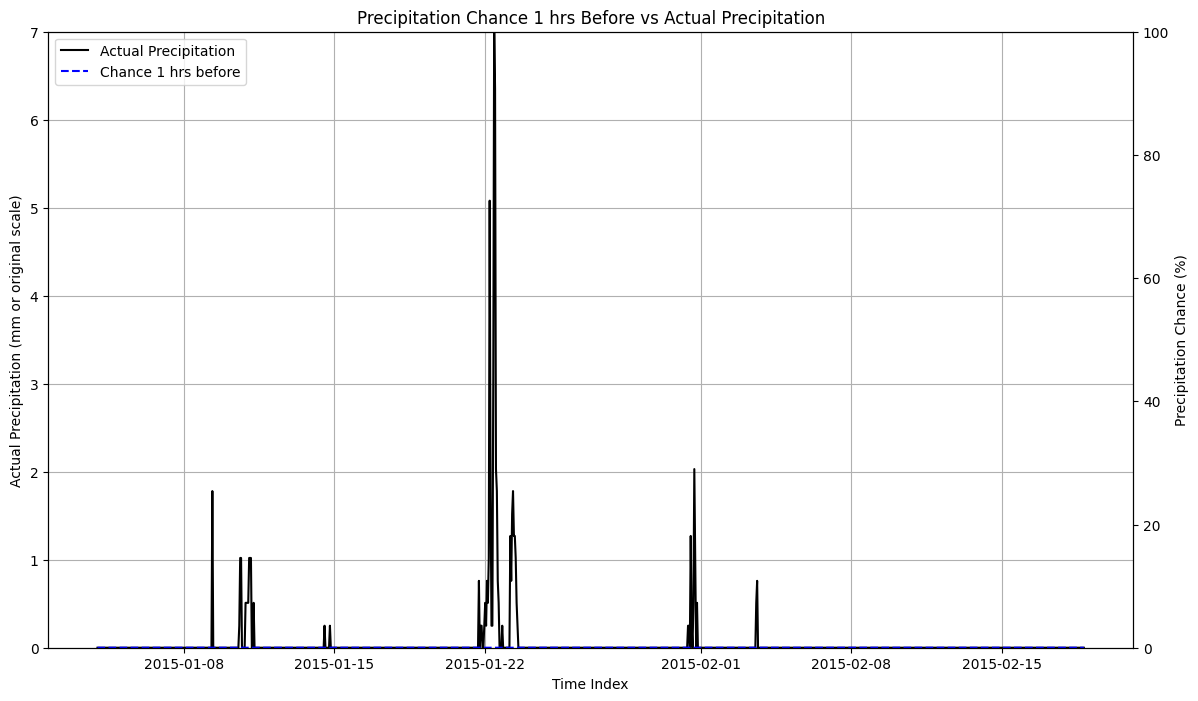

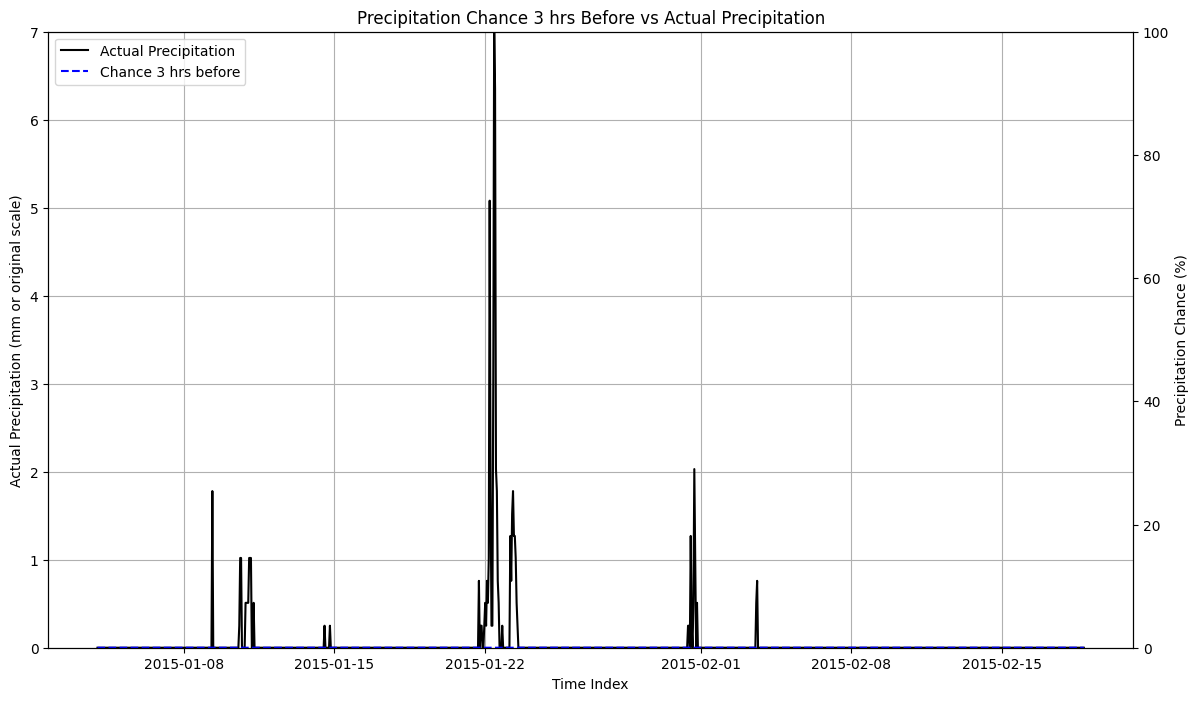

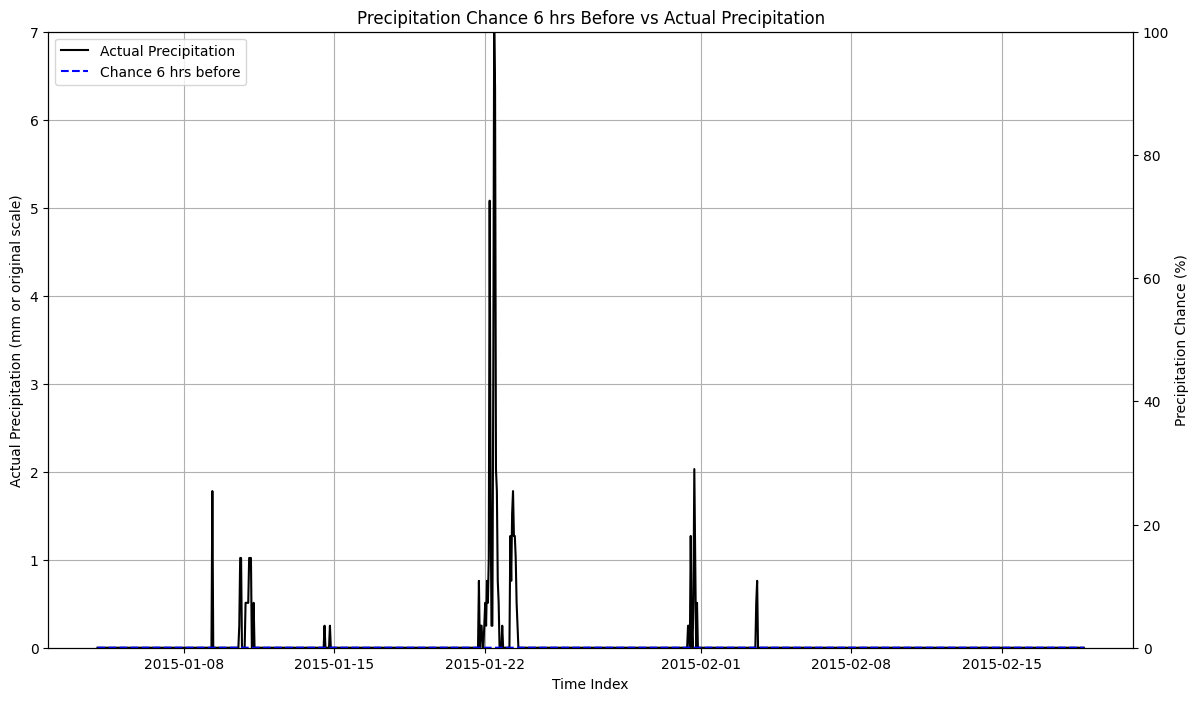

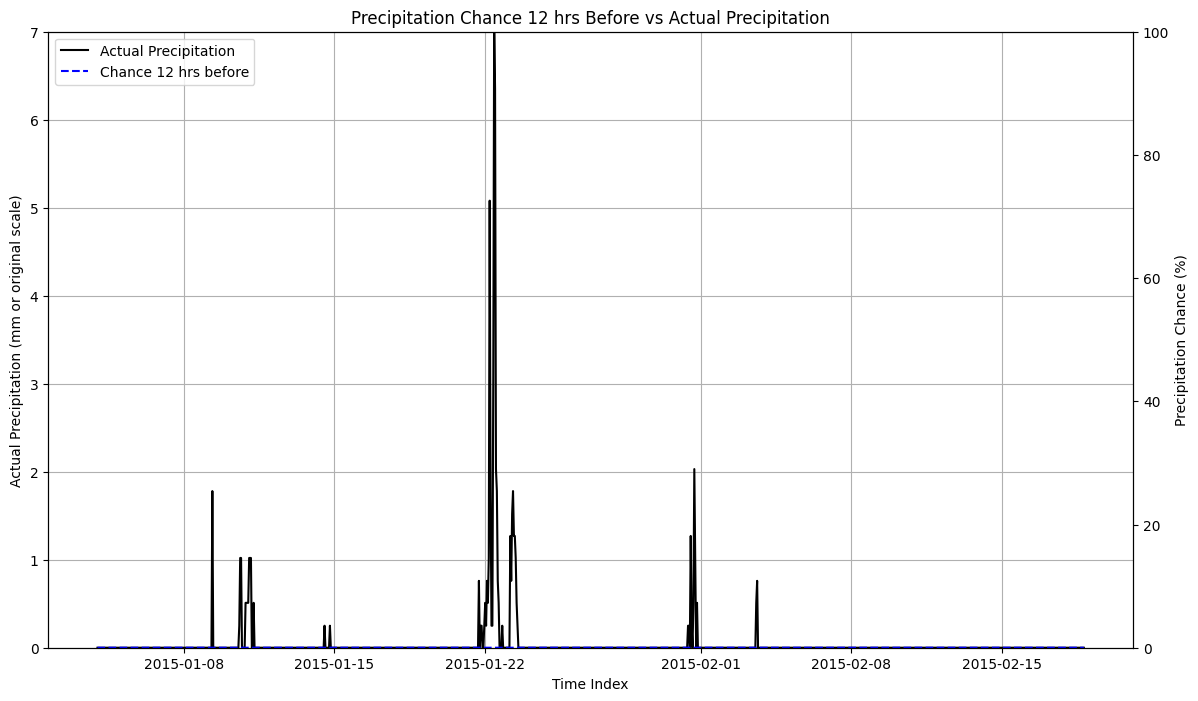

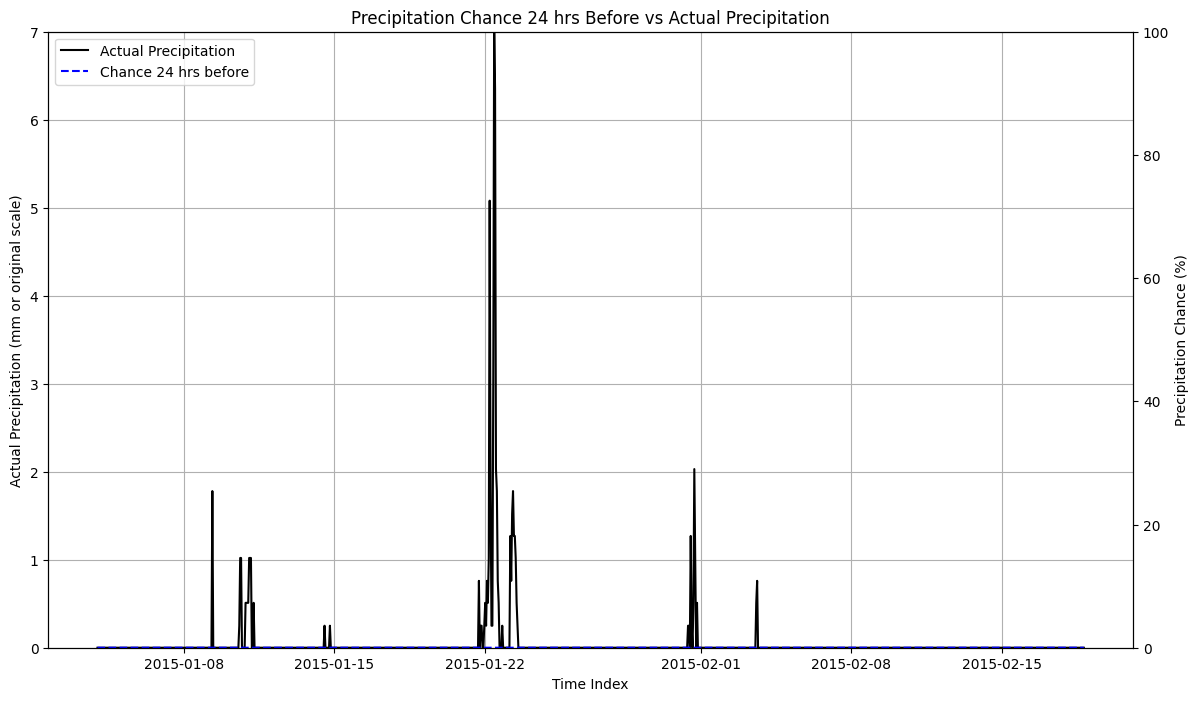

In [15]:
import matplotlib.pyplot as plt

def plot_precipitation_chances(df, target_intervals=[1, 3, 6, 12, 24], actual_column='Ppt', timeframe=(0, 100)):
    """
    Creates individual plots for each precipitation chance prediction interval, against actual precipitation values.
    
    Parameters:
        df (pd.DataFrame): DataFrame containing the precipitation chance columns and actual precipitation values.
        target_intervals (list): List of intervals (in hours) for which the precipitation chance is calculated.
        actual_column (str): Name of the actual precipitation column in the DataFrame.
        timeframe (tuple): Tuple (start, end) indicating the index range to plot for better visualization.
    """
    start, end = timeframe
    
    # Loop through each target interval and create a separate plot
    for interval in target_intervals:
        fig, ax1 = plt.subplots(figsize=(14, 8))
        
        # Plot actual precipitation values on the left y-axis
        ax1.plot(df.index[start:end], df[actual_column][start:end], label='Actual Precipitation', color='black', linewidth=1.5)
        ax1.set_xlabel('Time Index')
        ax1.set_ylabel('Actual Precipitation (mm or original scale)')
        ax1.set_ylim(0, 7)  # Keep the scale for actual precipitation
        ax1.grid(True)
        
        # Set up the secondary y-axis for precipitation chance as a percentage
        ax2 = ax1.twinx()
        
        # Plot the specific interval's precipitation chance, scaled to 0-100%
        ax2.plot(df.index[start:end], df[f'Ppt_pred_{interval}hr'][start:end] * 100, label=f'Chance {interval} hrs before', linestyle='--', color='blue')
        ax2.set_ylabel('Precipitation Chance (%)')
        ax2.set_ylim(0, 100)  # Scale to 0-100% for prediction chances
        
        # Add a combined legend
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
        
        plt.title(f'Precipitation Chance {interval} hrs Before vs Actual Precipitation')
        plt.show()

# Call the function with the adjusted timeframe
plot_precipitation_chances(aligned_full_data, timeframe=(0, 1100))


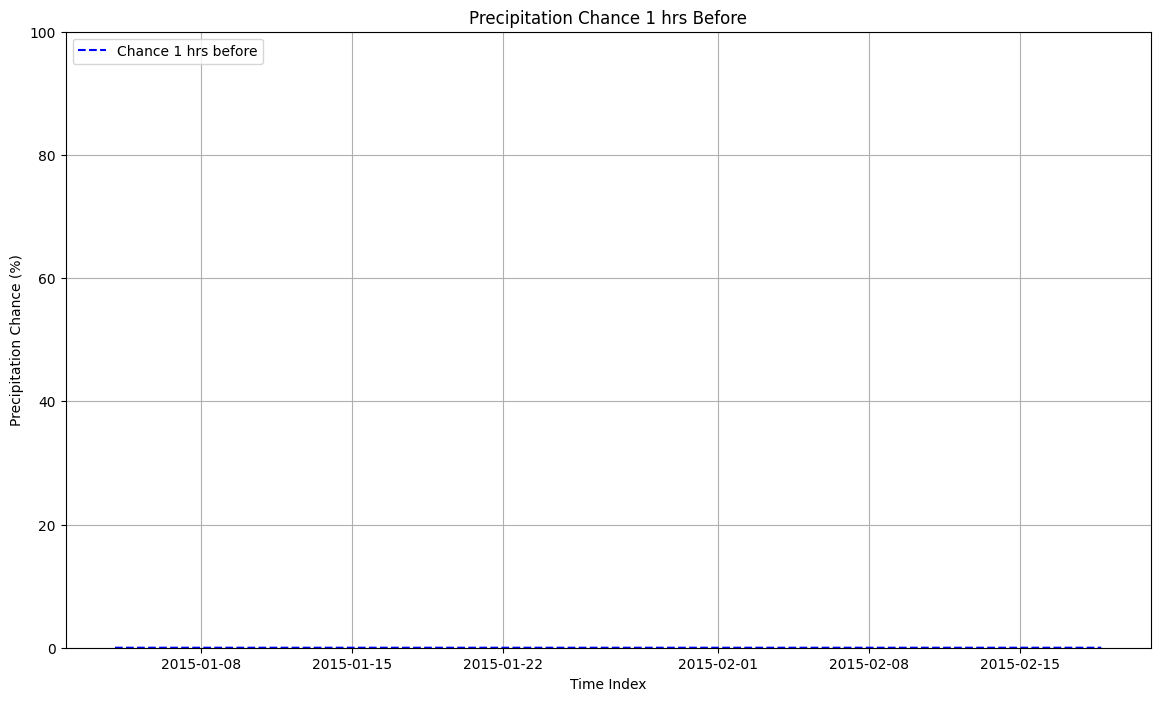

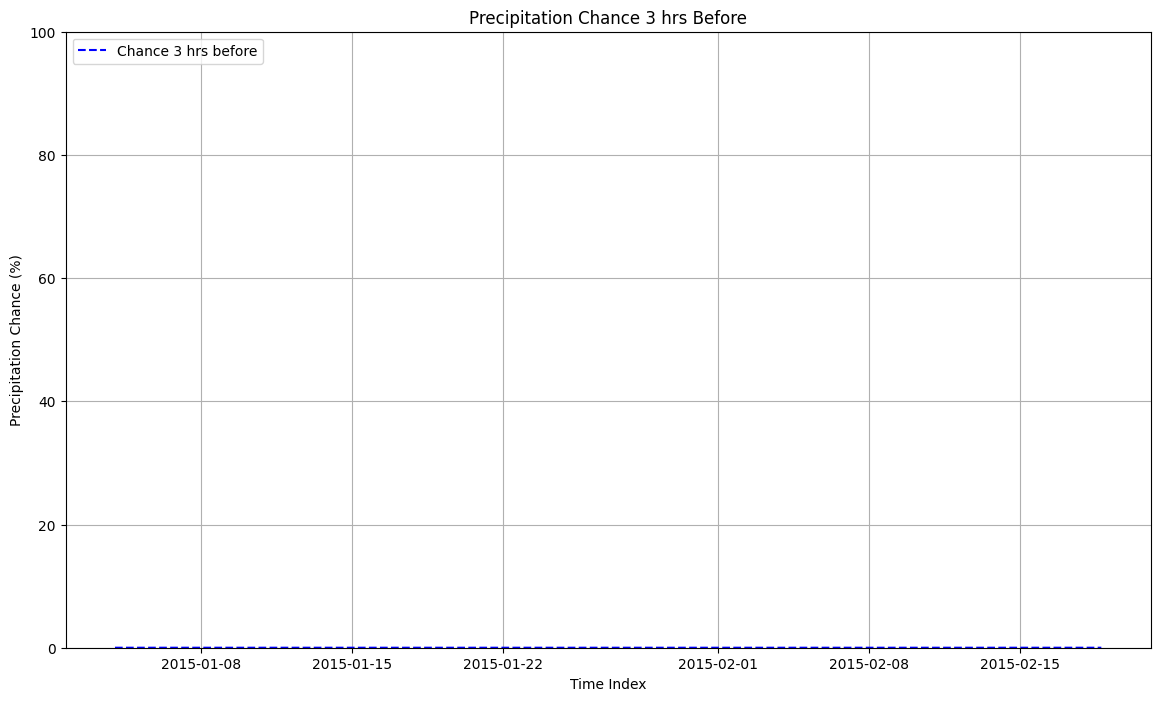

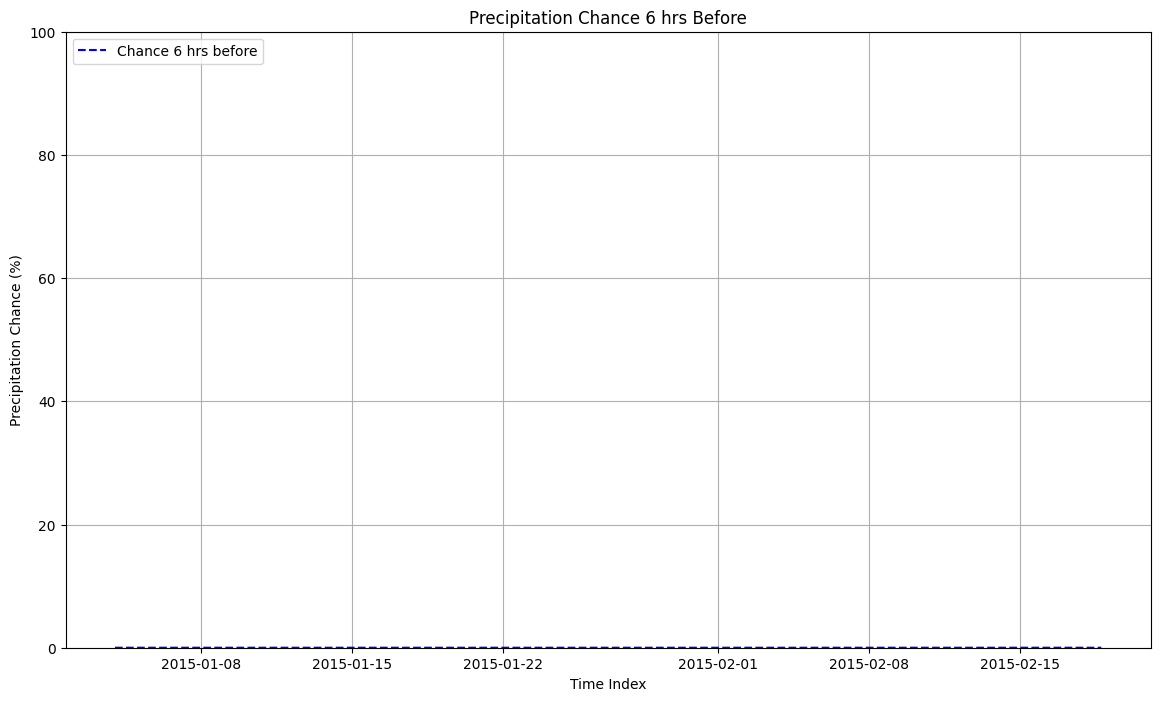

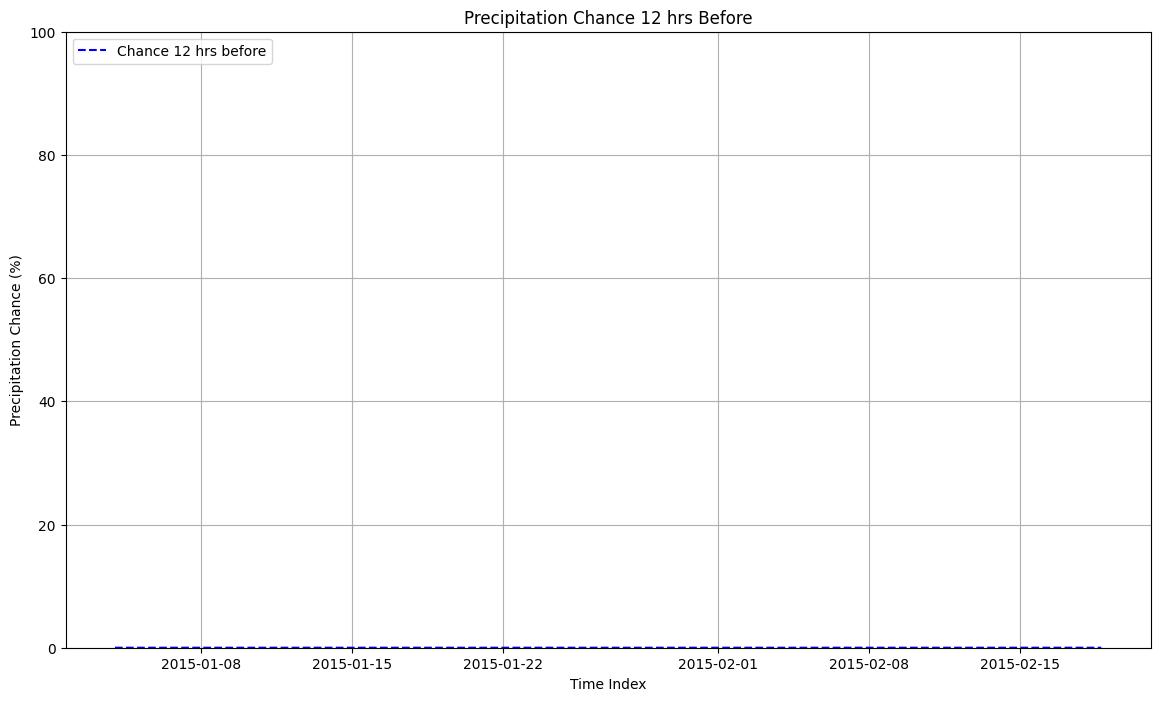

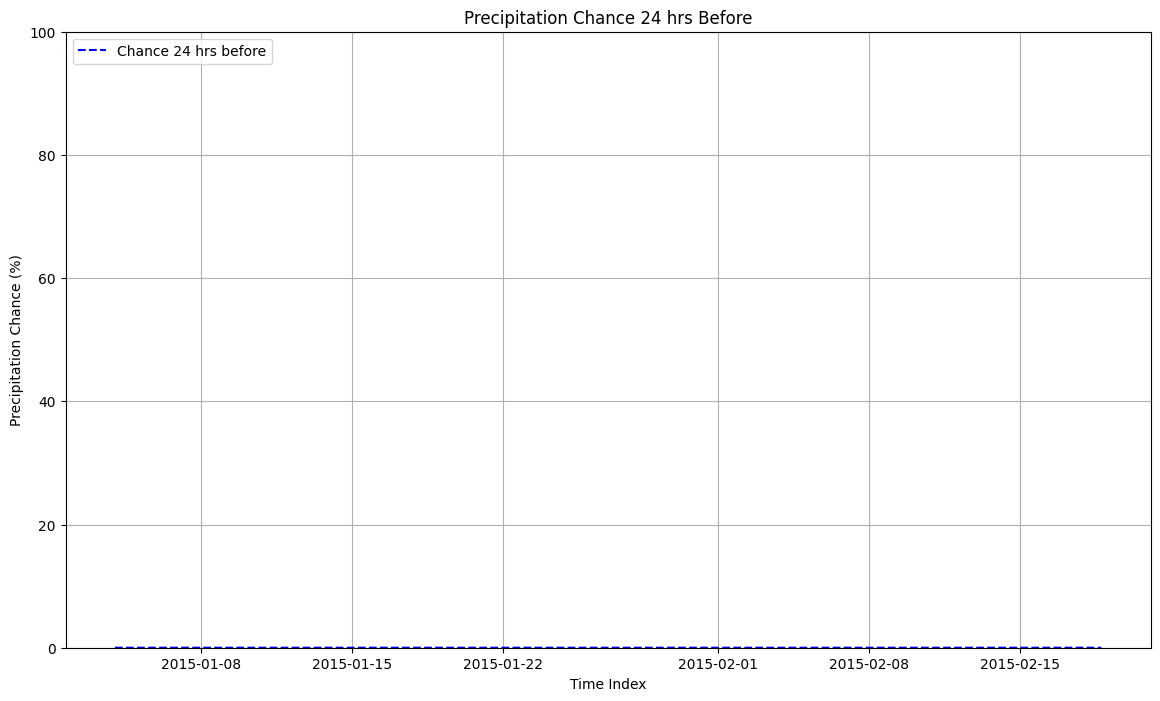

In [16]:

def plot_precipitation_chances_only(df, target_intervals=[1, 3, 6, 12, 24], timeframe=(0, 100)):
    """
    Creates individual plots for each precipitation chance prediction interval, without plotting actual precipitation values.
    
    Parameters:
        df (pd.DataFrame): DataFrame containing the precipitation chance columns.
        target_intervals (list): List of intervals (in hours) for which the precipitation chance is calculated.
        timeframe (tuple): Tuple (start, end) indicating the index range to plot for better visualization.
    """
    start, end = timeframe
    
    # Loop through each target interval and create a separate plot
    for interval in target_intervals:
        fig, ax2 = plt.subplots(figsize=(14, 8))
        
        # Plot the specific interval's precipitation chance, scaled to 0-100%
        ax2.plot(df.index[start:end], df[f'Ppt_pred_{interval}hr'][start:end] * 100, label=f'Chance {interval} hrs before', linestyle='--', color='blue')
        ax2.set_xlabel('Time Index')
        ax2.set_ylabel('Precipitation Chance (%)')
        ax2.set_ylim(0, 100)  # Scale to 0-100% for prediction chances
        ax2.grid(True)
        
        # Add legend
        ax2.legend(loc='upper left')
        
        plt.title(f'Precipitation Chance {interval} hrs Before')
        plt.show()

# Call the function with the adjusted timeframe
plot_precipitation_chances_only(aligned_full_data, timeframe=(0, 1100))


58369
Ppt_pred_1hr - NaNs: 0, Infs: 0


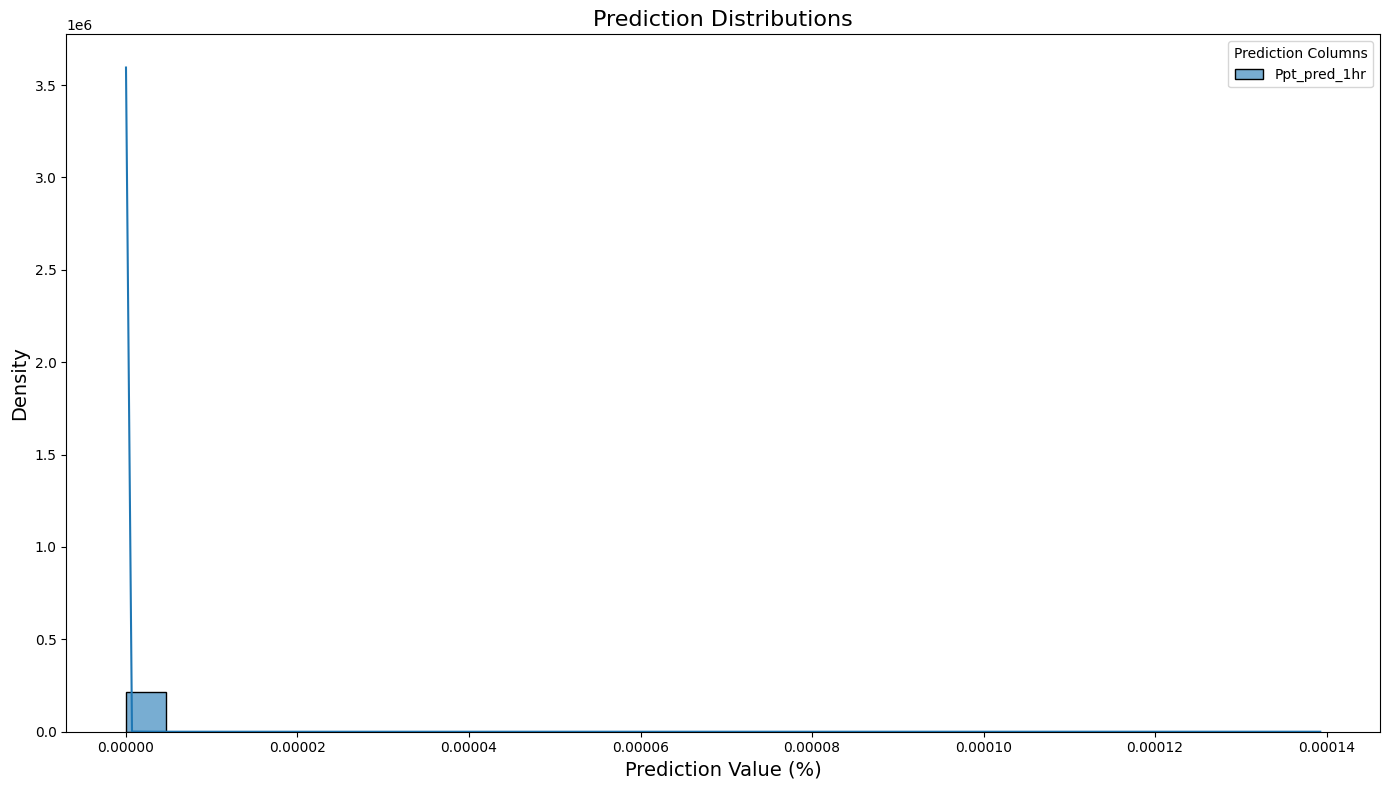

In [17]:
columns = ['Ppt_pred_1hr']
print(len(aligned_full_data))
for column in columns:
    print(f"{column} - NaNs: {aligned_full_data[column].isna().sum()}, Infs: {aligned_full_data[column].isin([np.inf, -np.inf]).sum()}")

plot_prediction_distributions(aligned_full_data, columns, bins=30)

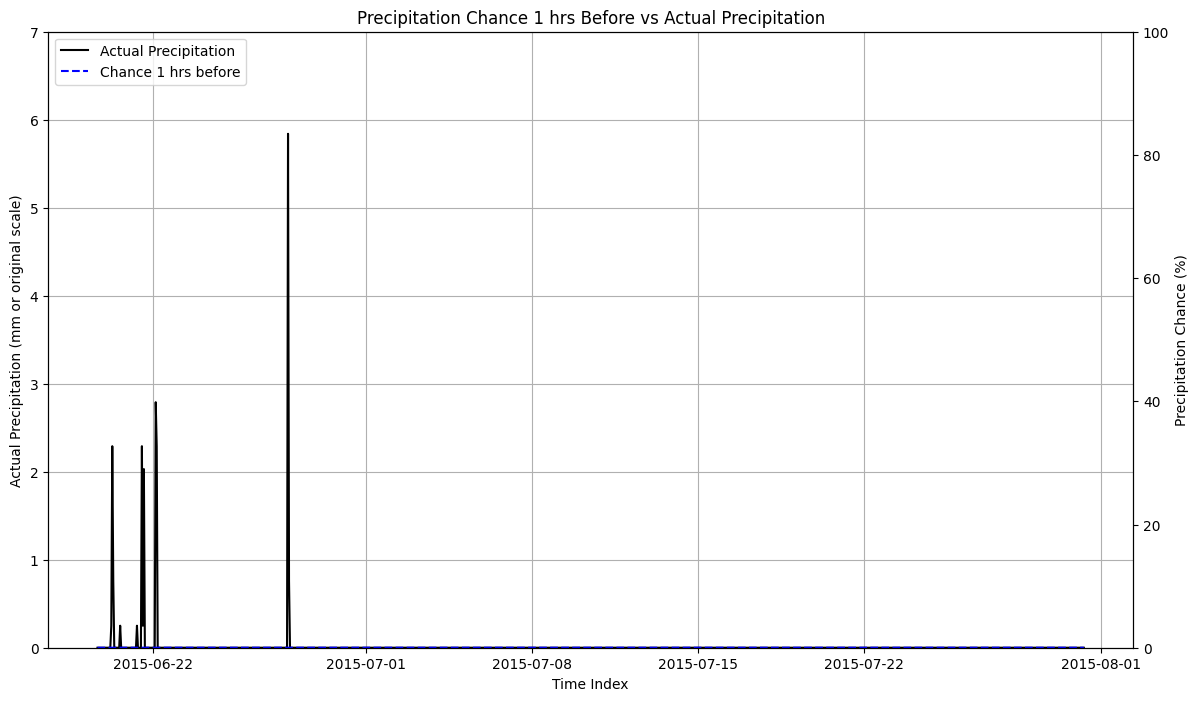

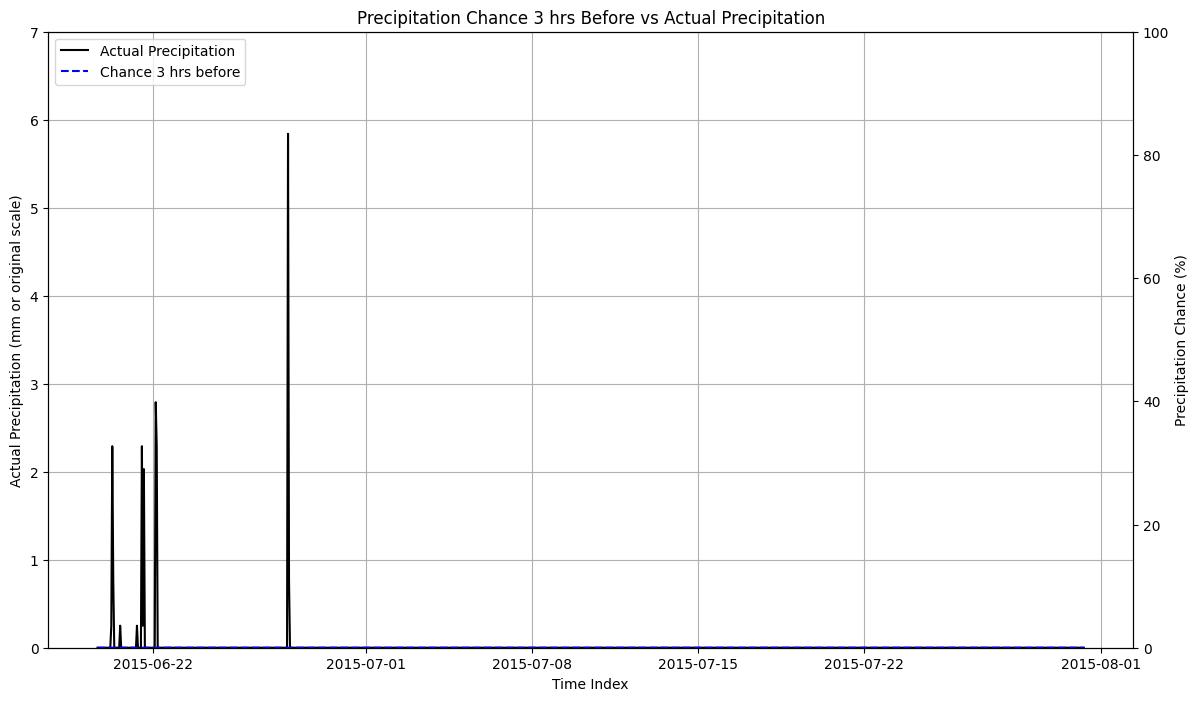

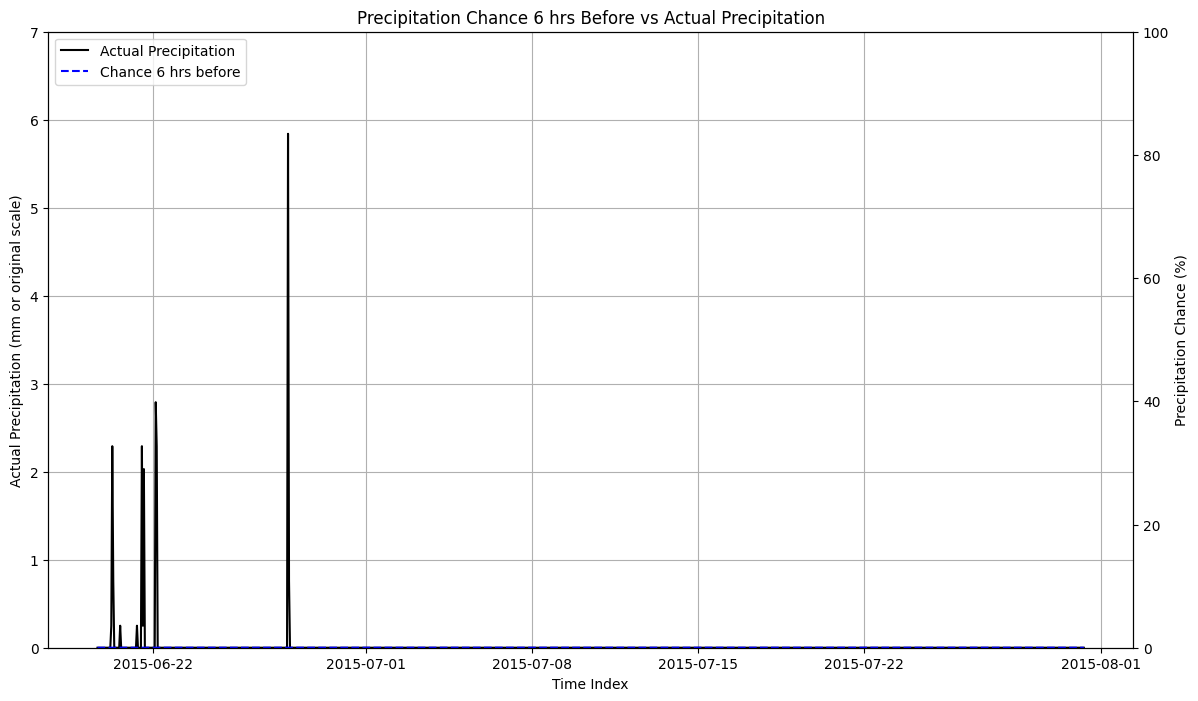

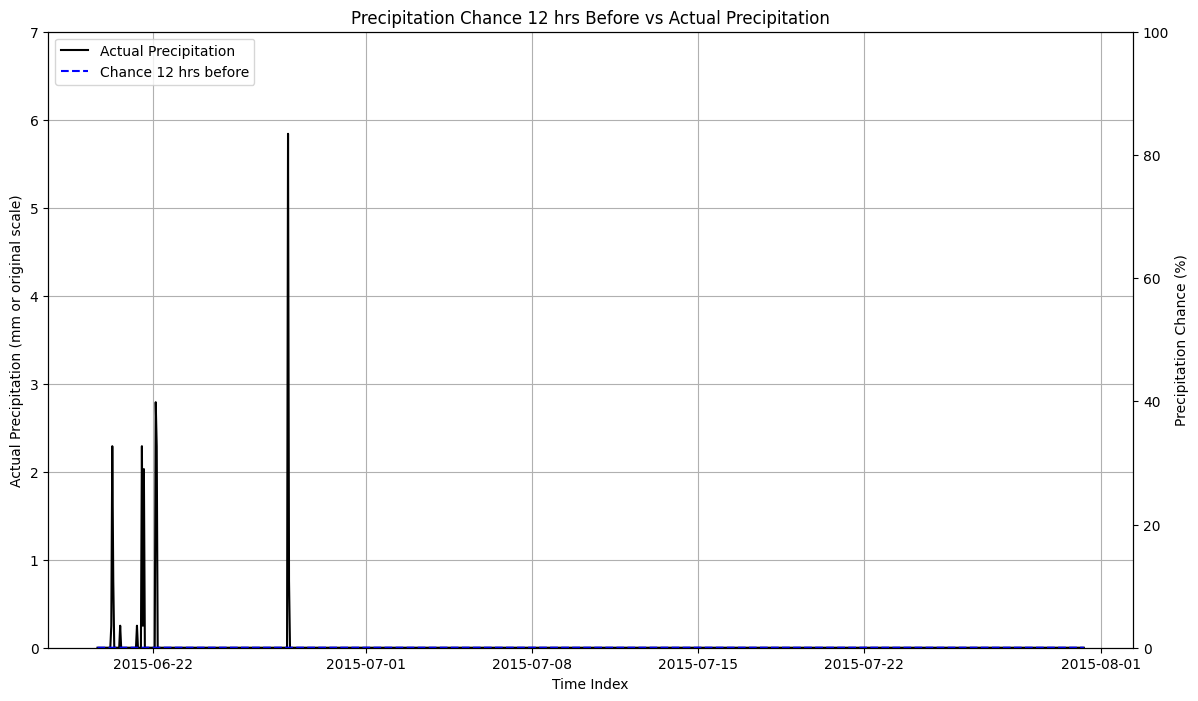

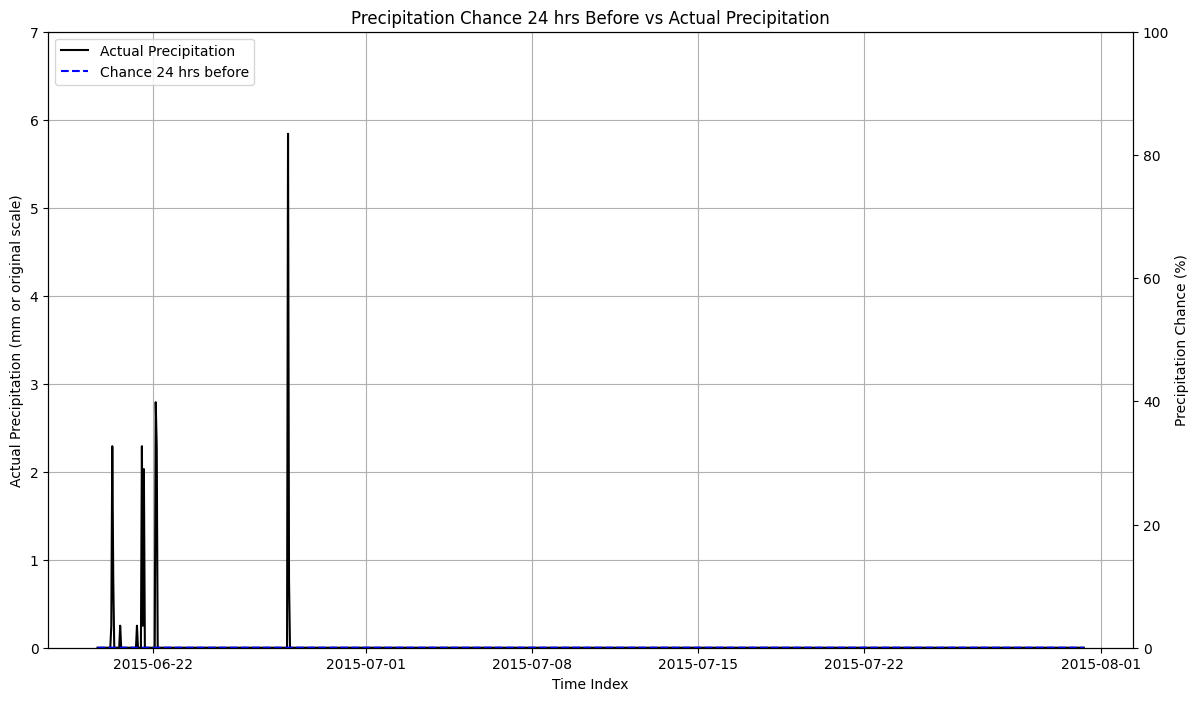

In [18]:
plot_precipitation_chances(aligned_full_data, timeframe=(4000, 5000))


In [19]:
train_df.columns

Index(['Ppt', 'RH', 'Srad', 'Day sin', 'Day cos', 'Year sin', 'Year cos',
       'Predicted_Rain_Next_Hour_1h', 'Predicted_Rain_Next_Hour_3h',
       'Predicted_Rain_Next_Hour_6h', 'Predicted_Rain_Next_Hour_12h',
       'Predicted_Rain_Next_Hour_24h', 'Rain_Chance_Percentage'],
      dtype='object')